 # B-BIND: SEA-AD MTG Example



 This notebook runs B-BIND on the SEA-AD Middle Temporal Gyrus (MTG) region

 as a worked example. It demonstrates the full pipeline:



 1. Configuration

 2. Data loading and preparation

 3. Model construction

 4. MCMC inference with convergence filtering

 5. Posterior inspection and validation plots



 **Data source:** Seattle Alzheimer's Disease Brain Cell Atlas (SEA-AD).

 Download from https://portal.brain-map.org/explore/seattle-alzheimers-disease



 **Citation:** If you use this code, please cite:

 Agrawal et al., Annals of Applied Statistics (in press). See CITATION.cff.

 ## 0. Imports

In [1]:
import sys
sys.path.insert(0, "..")   # so bbind/ is importable from notebooks/

import numpy as np
import numpy.ma as ma
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pickle

import jax
import jax.numpy as jnp

from src.model     import make_bbind_model
from src.inference import run_bbind, get_times
from src.utils     import (get_pca_donor_order, prepare_feature_block,
                              prepare_staging, suggest_priors, print_prior_suggestions)

print("JAX devices:", jax.devices())


JAX devices: [CpuDevice(id=0)]


 ## 1. Configuration



 Edit this cell to adapt the model to a new dataset.



 **obs_model options:**

 - `"negbin_exp"`     — count/density data growing from near-zero (exponential mean)

 - `"negbin_sigmoid"` — data that saturates at a ceiling (logistic mean)

 - `"ordinal"`        — discrete staging/grade variable (0-indexed integer)



 `prior_A` sets the HalfNormal scale on the NegBin dispersion parameter A.

 The MultivariateNormal priors on beta0/beta1 are shared across the measurement

 plate; adjust `prior_beta0_loc`, `prior_beta0_scale`, `prior_beta1_loc`,

 `prior_beta1_scale` if needed (see MEASUREMENT_CONFIG.md).

In [28]:
# ── Paths ──────────────────────────────────────────────────────────────────
NEUROPATH_CSV = "../data/SEA-AD-MTG-pathology.csv"
METADATA_CSV  = "../data/donor_metadata.csv"
RESULTS_PATH  = "results_seaad_mtg.pkl"

# ── Regions ────────────────────────────────────────────────────────────────
# Must match substrings in column names.  L = len(REGIONS).
REGIONS = ["Layer1","Layer2", "Layer3", "Layer4", "Layer5-6"]

# ── Measurement config ─────────────────────────────────────────────────────
# Per-measurement priors:
#   beta0_loc, beta0_scale  : Normal prior on log-baseline (exp block) or
#                             logit-baseline (sigm block) at t=0
#   beta1_scale             : HalfNormal scale on magnitude of change
#   beta1_direction         : +1 if marker increases with disease, -1 if decreases
#
# Run the "Suggested priors" cell below first to get data-driven starting
# values, then paste and adjust here.


measurement_config = [

    # Exponential-link block
    {"name": "percent 6e10 positive area",
     "type": "continuous", "obs_model": "negbin_exp",
     "beta0_loc": 0.0, "beta0_scale": 3.0, "beta1_scale": 3.0, "beta1_direction": 1},

    {"name": "number of 6e10 positive objects per area",
     "type": "continuous", "obs_model": "negbin_exp",
     "beta0_loc": 0.0, "beta0_scale": 3.0, "beta1_scale": 3.0, "beta1_direction": 1},

    {"name": "percent of Iba1 and 6e10 positive co-localized objects",
     "type": "continuous", "obs_model": "negbin_exp",
     "beta0_loc": 0.0, "beta0_scale": 3.0, "beta1_scale": 3.0, "beta1_direction": 1},

    {"name": "number of Iba1 and 6e10 positive co-localized objects per area",
     "type": "continuous", "obs_model": "negbin_exp",
     "beta0_loc": 0.0, "beta0_scale": 3.0, "beta1_scale": 3.0, "beta1_direction": 1},

    {"name": "percent AT8 positive area",
     "type": "continuous", "obs_model": "negbin_exp",
     "beta0_loc": 0.0, "beta0_scale": 3.0, "beta1_scale": 3.0, "beta1_direction": 1},

    {"name": "number of AT8 positive cells per area",
     "type": "continuous", "obs_model": "negbin_exp",
     "beta0_loc": 0.0, "beta0_scale": 3.0, "beta1_scale": 3.0, "beta1_direction": 1},

    # Sigmoid-link block
    {"name": "average 6e10 positive object area",
     "type": "continuous", "obs_model": "negbin_sigmoid",
     "beta0_loc": 0.0, "beta0_scale": 3.0, "beta1_scale": 3.0, "beta1_direction": 1},

    # Ordinal staging
    {"name": "Braak",
     "type": "ordinal", "n_categories": 6,
     "col": "Braak",
     "value_map": {
         "Braak 0": 0, "Braak I": 0, "Braak II": 1,
         "Braak III": 2, "Braak IV": 3, "Braak V": 4, "Braak VI": 5,
     }},

    {"name": "ADNC",
     "type": "ordinal", "n_categories": 4,
     "col": "Overall AD neuropathological Change",
     "value_map": {"Not AD": 0, "Low": 1, "Intermediate": 2, "High": 3}},
]

# Shared NegBin dispersion prior — one scale for all continuous measurements.
# Adjust if your scaled counts are much larger or smaller than ~500.
A_SCALE = 500.0

# ── Inference settings ─────────────────────────────────────────────────────
INFERENCE_CONFIG = dict(
    num_warmup     = 5000,
    num_samples    = 1000,
    num_chains     = 1,
    n_accepted     = 5,
    ess_threshold  = 50,
    rhat_threshold = 1.05,
    rng_seed       = 0,
    save_path      = RESULTS_PATH,
)


 ## 2. Load and clean data

In [29]:
quant_neuropath = pd.read_csv(NEUROPATH_CSV, index_col='Donor ID')
quant_neuropath.index = [str(i) for i in quant_neuropath.index]

# Drop columns not used by B-BIND
quant_neuropath.drop(
    quant_neuropath.columns[quant_neuropath.columns.str.startswith("total")],
    axis=1, inplace=True)
quant_neuropath.drop(
    quant_neuropath.columns[
        quant_neuropath.columns.str.startswith("number of") &
        ~quant_neuropath.columns.str.contains("per area")],
    axis=1, inplace=True)
for pat in ["area analyzed", "analysis region", "case number", "pTDP43", "aSyn", "Grey"]:
    quant_neuropath.drop(
        quant_neuropath.columns[quant_neuropath.columns.str.contains(pat)],
        axis=1, inplace=True)

metadata = pd.read_csv(METADATA_CSV, index_col=0)
metadata.index = [str(i) for i in metadata.index]

df = pd.merge(quant_neuropath, metadata, left_index=True, right_index=True)
print(f"Donors: {df.shape[0]}  |  Columns: {df.shape[1]}")


Donors: 84  |  Columns: 221


In [30]:
list(df.columns)

['Unnamed: 0',
 'percent AT8 positive area_Layer1',
 'percent AT8 positive area_Layer2',
 'percent AT8 positive area_Layer3',
 'percent AT8 positive area_Layer4',
 'percent AT8 positive area_Layer5-6',
 'average AT8 positive cell area_Layer1',
 'average AT8 positive cell area_Layer2',
 'average AT8 positive cell area_Layer3',
 'average AT8 positive cell area_Layer4',
 'average AT8 positive cell area_Layer5-6',
 'number of AT8 positive cells per area_Layer1',
 'number of AT8 positive cells per area_Layer2',
 'number of AT8 positive cells per area_Layer3',
 'number of AT8 positive cells per area_Layer4',
 'number of AT8 positive cells per area_Layer5-6',
 'percent Iba1 positive area_Layer1',
 'percent Iba1 positive area_Layer2',
 'percent Iba1 positive area_Layer3',
 'percent Iba1 positive area_Layer4',
 'percent Iba1 positive area_Layer5-6',
 'number of 6e10 positive objects per area_Layer1',
 'number of 6e10 positive objects per area_Layer2',
 'number of 6e10 positive objects per area_

 ## 3. Donor ordering and data preparation

In [31]:
feat_cols    = quant_neuropath.columns.tolist()
initial_cond = get_pca_donor_order(df[feat_cols])
T = len(initial_cond)
L = len(REGIONS)
print(f"T={T} donors  |  L={L} regions")


T=84 donors  |  L=5 regions


In [32]:
# Separate feature lists by obs model type
exp_names  = [c["name"] for c in measurement_config
              if c["type"] == "continuous" and c["obs_model"] == "negbin_exp"]
sigm_names = [c["name"] for c in measurement_config
              if c["type"] == "continuous" and c["obs_model"] == "negbin_sigmoid"]
ord_cfg    = [c for c in measurement_config if c["type"] == "ordinal"]

# Build (M, L, T) scaled integer arrays
data_exp,  mask_exp  = prepare_feature_block(df, exp_names,  REGIONS, initial_cond)
data_sigm, mask_sigm = prepare_feature_block(df, sigm_names, REGIONS, initial_cond)

print(f"Exponential block : {data_exp.shape}   (M={len(exp_names)}, L={L}, T={T})")
print(f"Sigmoid block     : {data_sigm.shape}  (M={len(sigm_names)}, L={L}, T={T})")


Exponential block : (6, 5, 84)   (M=6, L=5, T=84)
Sigmoid block     : (1, 5, 84)  (M=1, L=5, T=84)


In [33]:
ord_cfg

[{'name': 'Braak',
  'type': 'ordinal',
  'n_categories': 6,
  'col': 'Braak',
  'value_map': {'Braak 0': 0,
   'Braak I': 0,
   'Braak II': 1,
   'Braak III': 2,
   'Braak IV': 3,
   'Braak V': 4,
   'Braak VI': 5}},
 {'name': 'ADNC',
  'type': 'ordinal',
  'n_categories': 4,
  'col': 'Overall AD neuropathological Change',
  'value_map': {'Not AD': 0, 'Low': 1, 'Intermediate': 2, 'High': 3}}]

In [34]:
# Staging integer arrays (0-indexed, reordered by initial_cond)
staging_obs, staging_masks = prepare_staging(df, ord_cfg, initial_cond)
for name, arr in staging_obs.items():
    n_valid = staging_masks[name].sum()
    print(f"  {name}: {n_valid}/{T} donors valid  |  "
          f"range {arr[staging_masks[name]].min()}–{arr[staging_masks[name]].max()}")


  Braak: 84/84 donors valid  |  range 0–5
  ADNC: 84/84 donors valid  |  range 0–3


 ### Data overview

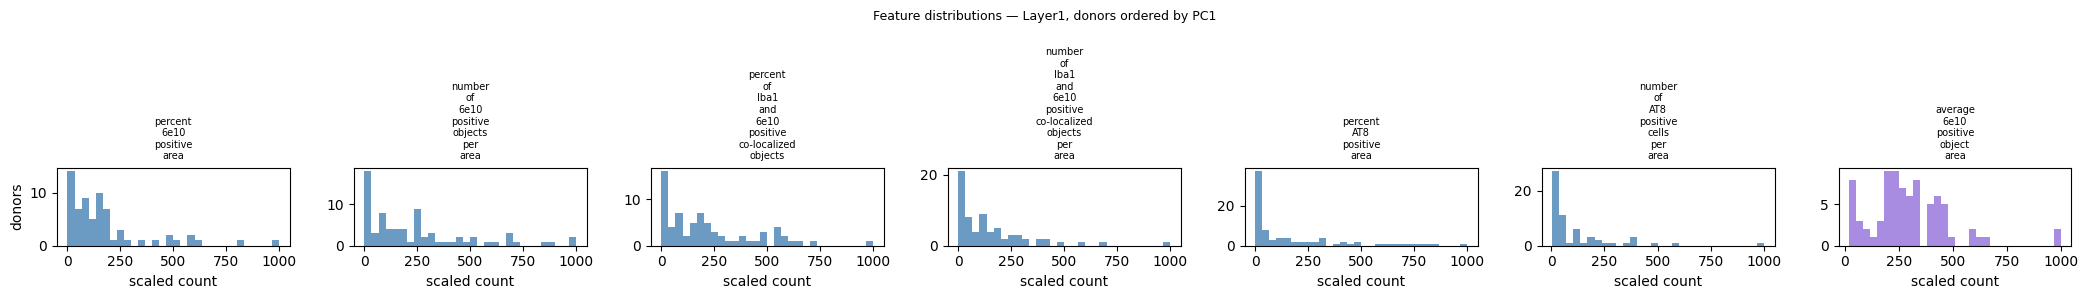

In [35]:
all_names = exp_names + sigm_names
n_feats   = len(all_names)
fig, axes = plt.subplots(1, n_feats, figsize=(3 * n_feats, 3))

for i, (ax, name) in enumerate(zip(axes, all_names)):
    if i < len(exp_names):
        vals = data_exp[i, 0, :]         # first region (REGIONS[0])
        color = "steelblue"
    else:
        vals = data_sigm[i - len(exp_names), 0, :]
        color = "mediumpurple"
    ax.hist(vals[vals > 0], bins=30, color=color, alpha=0.8)
    ax.set_title(name.replace(" ", "\n"), fontsize=7)
    ax.set_xlabel("scaled count")

axes[0].set_ylabel("donors")
plt.suptitle(f"Feature distributions — {REGIONS[0]}, donors ordered by PC1", fontsize=9)
plt.tight_layout()
plt.show()


 ### Suggested priors from data



 This cell computes data-driven prior suggestions for each measurement using

 the early and late donors (bottom and top 25% of PC1 ordering) as proxies

 for low and high pseudotime. Review the output, adjust `beta1_direction`

 based on biology, and paste the values into the measurement config above.

In [36]:
exp_suggestions  = suggest_priors(data_exp,  mask_exp,  exp_names,  early_frac=0.25, late_frac=0.25)
sigm_suggestions = suggest_priors(data_sigm, mask_sigm, sigm_names, early_frac=0.25, late_frac=0.25)

print("=== Exponential block ===")
print_prior_suggestions(exp_suggestions)
print("=== Sigmoid block ===")
print_prior_suggestions(sigm_suggestions)


=== Exponential block ===
Suggested per-measurement priors (edit before using):

  percent 6e10 positive area
    beta0_loc=1.96,  beta0_scale=3.0
    beta1_scale=3.85,  beta1_direction=+1 (increases)

  number of 6e10 positive objects per area
    beta0_loc=2.88,  beta0_scale=3.0
    beta1_scale=3.14,  beta1_direction=+1 (increases)

  percent of Iba1 and 6e10 positive co-localized objects
    beta0_loc=2.54,  beta0_scale=3.0
    beta1_scale=3.59,  beta1_direction=+1 (increases)

  number of Iba1 and 6e10 positive co-localized objects per area
    beta0_loc=2.04,  beta0_scale=3.0
    beta1_scale=3.69,  beta1_direction=+1 (increases)

  percent AT8 positive area
    beta0_loc=2.51,  beta0_scale=3.0
    beta1_scale=3.42,  beta1_direction=+1 (increases)

  number of AT8 positive cells per area
    beta0_loc=2.22,  beta0_scale=3.0
    beta1_scale=3.66,  beta1_direction=+1 (increases)

=== Sigmoid block ===
Suggested per-measurement priors (edit before using):

  average 6e10 positive obje

 After reviewing the suggestions above, update beta0_loc, beta1_scale, and

 beta1_direction in the measurement_config cell at the top, then re-run

 from Section 1 downward before running inference.

In [39]:
# Build a lookup from name -> suggestion
suggestions_lookup = {s["name"]: s for s in exp_suggestions + sigm_suggestions}

# Update measurement_config in-place with suggested priors
for cfg in measurement_config:
    if cfg["name"] in suggestions_lookup:
        s = suggestions_lookup[cfg["name"]]
        cfg.update({
            "beta0_loc":       s["beta0_loc"],
            "beta0_scale":     s["beta0_scale"],
            "beta1_scale":     s["beta1_scale"],
            "beta1_direction": s["beta1_direction"],
        })

# Inspect result
for cfg in measurement_config:
    if cfg["type"] == "continuous":
        print(f"{cfg['name'][:45]:<45}  "
              f"beta0_loc={cfg['beta0_loc']:+.2f}  "
              f"beta1_scale={cfg['beta1_scale']:.2f}  "
              f"direction={cfg['beta1_direction']:+d}")

percent 6e10 positive area                     beta0_loc=+1.96  beta1_scale=3.85  direction=+1
number of 6e10 positive objects per area       beta0_loc=+2.88  beta1_scale=3.14  direction=+1
percent of Iba1 and 6e10 positive co-localize  beta0_loc=+2.54  beta1_scale=3.59  direction=+1
number of Iba1 and 6e10 positive co-localized  beta0_loc=+2.04  beta1_scale=3.69  direction=+1
percent AT8 positive area                      beta0_loc=+2.51  beta1_scale=3.42  direction=+1
number of AT8 positive cells per area          beta0_loc=+2.22  beta1_scale=3.66  direction=+1
average 6e10 positive object area              beta0_loc=+4.82  beta1_scale=1.37  direction=+1


In [40]:
# manual override if needed - example
# Manual override after auto-update
next(c for c in measurement_config 
     if c["name"] == "percent of Iba1 and 6e10 positive co-localized objects"
)["beta1_direction"] = 1

 ## 4. Build model and run MCMC

In [41]:
model = make_bbind_model(measurement_config, A_scale=A_SCALE)

model_args   = (
    jnp.array(data_exp),
    jnp.array(data_sigm),
    jnp.array(mask_exp),
    jnp.array(mask_sigm),
)
model_kwargs = dict(
    staging_obs   = {k: jnp.array(v) for k, v in staging_obs.items()},
    staging_masks = {k: jnp.array(v) for k, v in staging_masks.items()},
)


In [42]:
# Run inference. Results are saved to RESULTS_PATH automatically.
# To reload without re-running: uncomment the block below instead.
results = run_bbind(model, model_args, model_kwargs, **INFERENCE_CONFIG)

# --- To reload saved results:
# with open(RESULTS_PATH, "rb") as f:
#     results = pickle.load(f)


Attempt 1  (seed=0)  —  0/5 accepted so far


sample: 100%|██████████| 6000/6000 [01:07<00:00, 89.33it/s, 127 steps of size 4.66e-02. acc. prob=0.89] 


  Accepted  (min ESS=89.4, max r-hat=1.010)
Attempt 2  (seed=1)  —  1/5 accepted so far


sample: 100%|██████████| 6000/6000 [01:02<00:00, 95.40it/s, 63 steps of size 5.03e-02. acc. prob=0.88]  


  Accepted  (min ESS=119.4, max r-hat=1.004)
Attempt 3  (seed=2)  —  2/5 accepted so far


...

  Accepted  (min ESS=122.2, max r-hat=1.004)
Attempt 4  (seed=3)  —  3/5 accepted so far


sample: 100%|██████████| 6000/6000 [01:01<00:00, 97.47it/s, 63 steps of size 4.96e-02. acc. prob=0.88]  


  Accepted  (min ESS=56.3, max r-hat=1.014)
Attempt 5  (seed=4)  —  4/5 accepted so far


sample: 100%|██████████| 6000/6000 [01:07<00:00, 88.30it/s, 127 steps of size 4.27e-02. acc. prob=0.91] 


  Accepted  (min ESS=120.6, max r-hat=1.015)
Saved to results_seaad_mtg.pkl


 ## 5. Posterior inspection

In [43]:
times_all, times_mean, times_std = get_times(results)
print(f"Pooled posterior: {times_all.shape}  (runs x samples, donors)")


Pooled posterior: (5000, 84)  (runs x samples, donors)


 ### 5a. Pseudotime distribution across donors

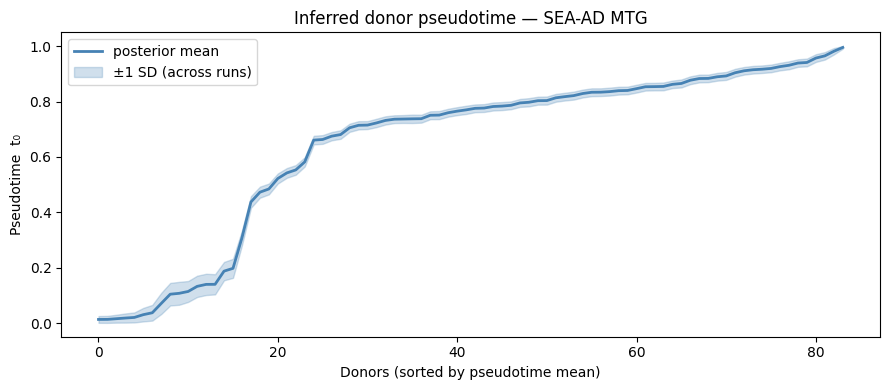

In [44]:
sort_idx = np.argsort(times_mean)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(T), times_mean[sort_idx],
        color="steelblue", lw=2, label="posterior mean")
ax.fill_between(
    np.arange(T),
    (times_mean + times_std)[sort_idx],
    (times_mean - times_std)[sort_idx],
    color="steelblue", alpha=0.25, label="±1 SD (across runs)",
)
ax.set_xlabel("Donors (sorted by pseudotime mean)")
ax.set_ylabel("Pseudotime  t₀")
ax.set_title("Inferred donor pseudotime — SEA-AD MTG")
ax.legend()
plt.tight_layout()
plt.show()


 ### 5b. Correlation with staging metrics

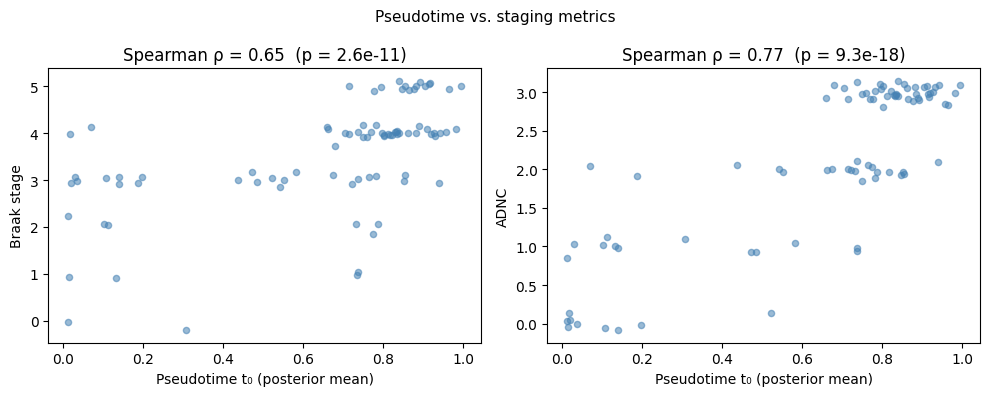

In [46]:
braak_int = df["Braak"].map({
    "Braak 0": 0, "Braak I": 0, "Braak II": 1,
    "Braak III": 2, "Braak IV": 3, "Braak V": 4, "Braak VI": 5,
}).values[initial_cond].astype(float)

adnc_int = df["Overall AD neuropathological Change"].map(
    {"Not AD": 0, "Low": 1, "Intermediate": 2, "High": 3}
).values[initial_cond].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, vals, label in zip(
    axes,
    [braak_int, adnc_int],
    ["Braak stage", "ADNC"],
):
    valid = ~np.isnan(vals)
    rho, pval = stats.spearmanr(times_mean[valid], vals[valid])
    # jitter ordinal values slightly for visibility
    jitter = 0.08 * np.random.randn(valid.sum())
    ax.scatter(times_mean[valid], vals[valid] + jitter,
               alpha=0.55, s=20, color="steelblue")
    ax.set_xlabel("Pseudotime t₀ (posterior mean)")
    ax.set_ylabel(label)
    ax.set_title(f"Spearman ρ = {rho:.2f}  (p = {pval:.1e})")

plt.suptitle("Pseudotime vs. staging metrics", fontsize=11)
plt.tight_layout()
plt.show()


# ### 5c. Kinetic fits — observed data vs. posterior mean curve
#
# Each panel shows one measurement (row) × one region (column).
# Red curve: posterior mean of A·exp(β₀ + β₁·t) over the t0 grid.

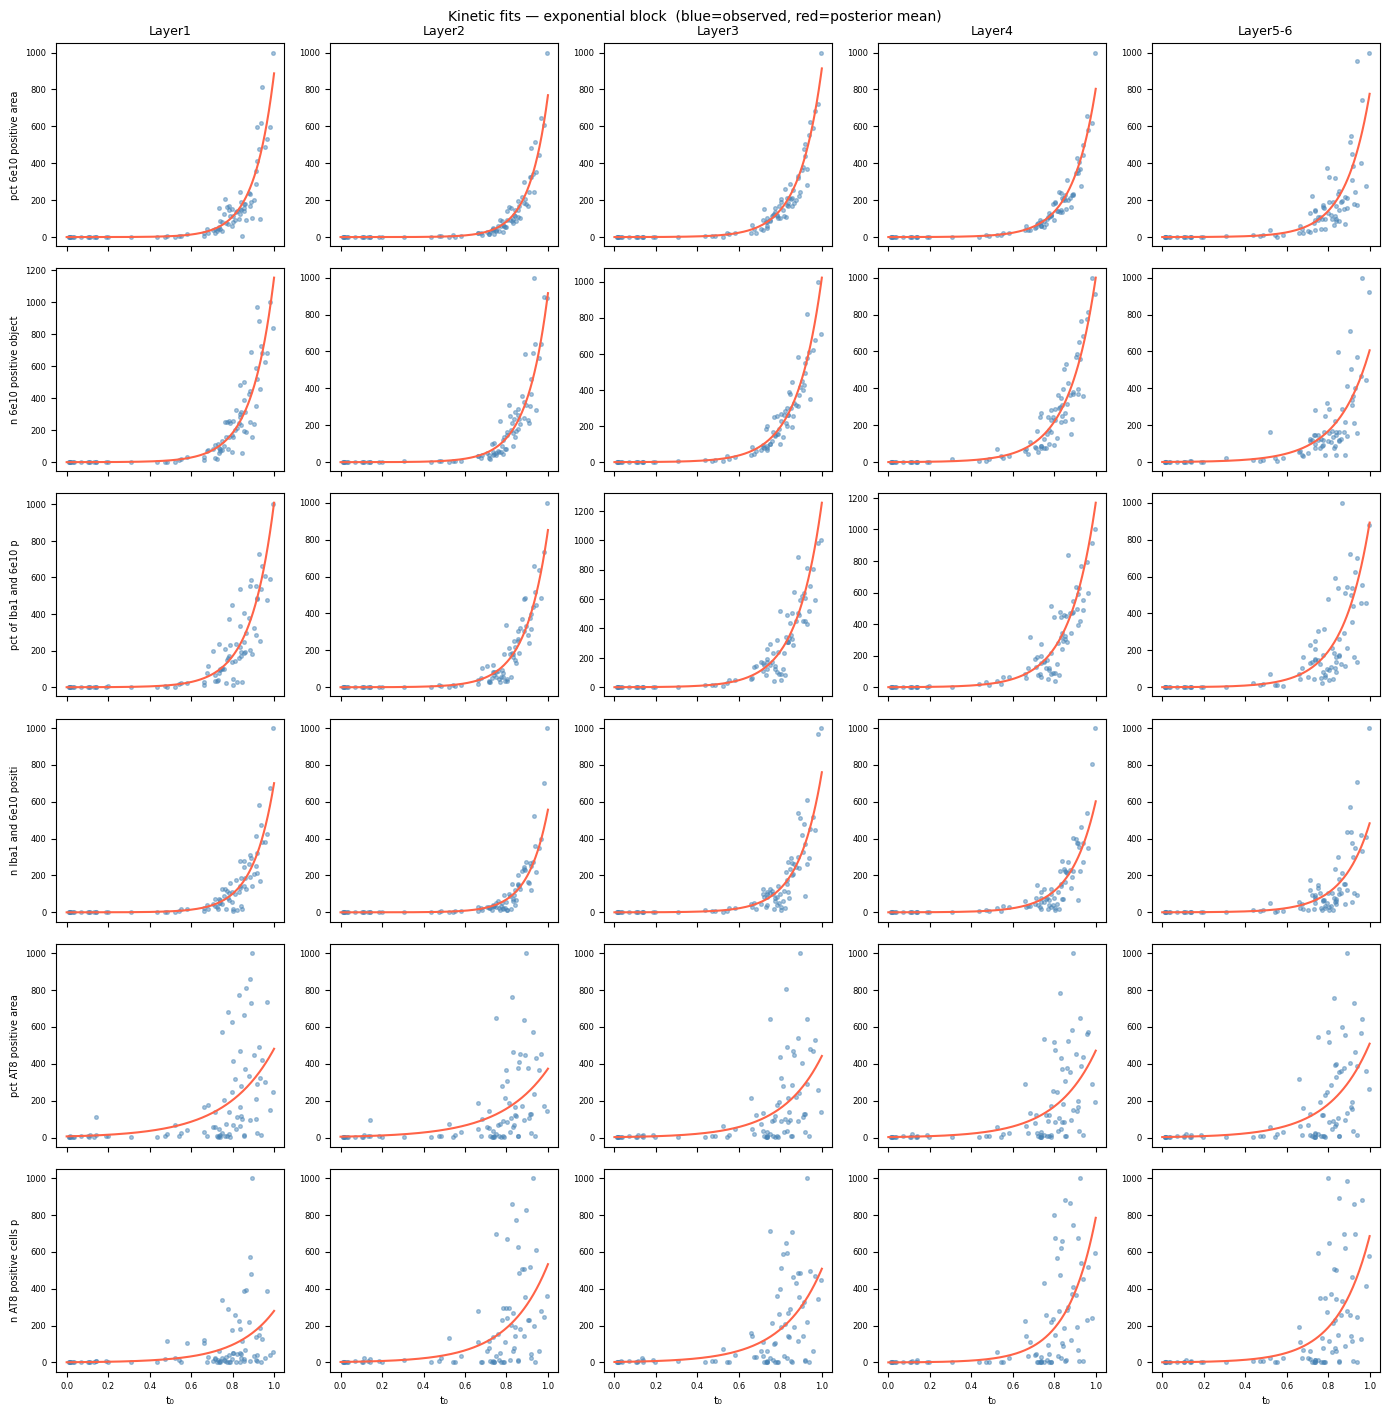

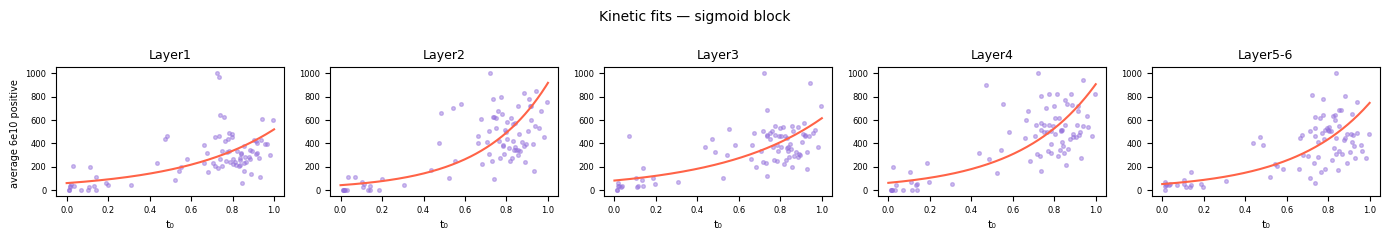

In [ ]:

 
# %%
samples = results["posterior_samples"][-1]   # last accepted run
beta0_exp_mean = samples["beta0_exp"].mean(0)  # (M_exp, L)
beta1_exp_mean = samples["beta1_exp"].mean(0)  # (M_exp, L)
A_exp_mean     = samples["A_exp"].mean(0)      # (M_exp, L)
 
# Recover per-measurement directions from config
exp_directions = [c["beta1_direction"] for c in measurement_config
                  if c["type"] == "continuous" and c["obs_model"] == "negbin_exp"]
 
t_grid = np.linspace(0, 1, 200)
 
fig, axes = plt.subplots(
    len(exp_names), L,
    figsize=(2.8 * L, 2.4 * len(exp_names)),
    sharex=True, sharey=False,
)
 
for m, (feat, direction) in enumerate(zip(exp_names, exp_directions)):
    for l, region in enumerate(REGIONS):
        ax = axes[m, l]
        valid = mask_exp[m, l, :]
        ax.scatter(times_mean[valid], data_exp[m, l, valid],
                   s=7, alpha=0.45, color="steelblue")
        logits = beta0_exp_mean[m, l] + direction * beta1_exp_mean[m, l] * t_grid
        mu = A_exp_mean[m, l] * np.exp(logits)   # NegBin mean = A * exp(logits)
        ax.plot(t_grid, mu, color="tomato", lw=1.5)
        if m == 0:
            ax.set_title(region, fontsize=9)
        if l == 0:
            short = feat.replace("percent", "pct").replace("number of", "n")
            ax.set_ylabel(short[:22], fontsize=7)
        ax.tick_params(labelsize=6)
 
for l in range(L):
    axes[-1, l].set_xlabel("t₀", fontsize=8)
 
fig.suptitle("Kinetic fits — exponential block  (blue=observed, red=posterior mean)",
             fontsize=10)
plt.tight_layout()
plt.show()
 
# %%
# Sigmoid block
# samples["beta0_sigm"] shape: (n_samples, M_sigm, L)
beta0_sigm_mean = samples["beta0_sigm"].mean(0)  # (M_sigm, L)
beta1_sigm_mean = samples["beta1_sigm"].mean(0)  # (M_sigm, L)
A_sigm_mean     = samples["A_sigm"].mean(0)      # (M_sigm, L)
 
# Recover per-measurement directions from config (same order as sigm_names)
sigm_directions = [c["beta1_direction"] for c in measurement_config
                   if c["type"] == "continuous" and c["obs_model"] == "negbin_sigmoid"]
 
from scipy.special import expit   # sigmoid, avoids JAX dependency in plotting
 
fig, axes = plt.subplots(
    len(sigm_names), L,
    figsize=(2.8 * L, 2.4 * len(sigm_names)),
    sharex=True,
)
if len(sigm_names) == 1:
    axes = axes[np.newaxis, :]
 
for m, (feat, direction) in enumerate(zip(sigm_names, sigm_directions)):
    for l, region in enumerate(REGIONS):
        ax = axes[m, l]
        valid = mask_sigm[m, l, :]
        ax.scatter(times_mean[valid], data_sigm[m, l, valid],
                   s=7, alpha=0.45, color="mediumpurple")
        logit_val = beta0_sigm_mean[m, l] + direction * beta1_sigm_mean[m, l] * t_grid
        probs = expit(logit_val)
        probs = np.clip(probs, 1e-6, 1 - 1e-6)
        mu = A_sigm_mean[m, l] * probs / (1 - probs)   # NegBin mean = A*p/(1-p)
        ax.plot(t_grid, mu, color="tomato", lw=1.5)
        if m == 0:
            ax.set_title(region, fontsize=9)
        if l == 0:
            ax.set_ylabel(feat[:22], fontsize=7)
        ax.tick_params(labelsize=6)
 
for l in range(L):
    axes[-1, l].set_xlabel("t₀", fontsize=8)
 
fig.suptitle("Kinetic fits — sigmoid block", fontsize=10)
plt.tight_layout()
plt.show()

 ### 5d. Staging posterior predictive check

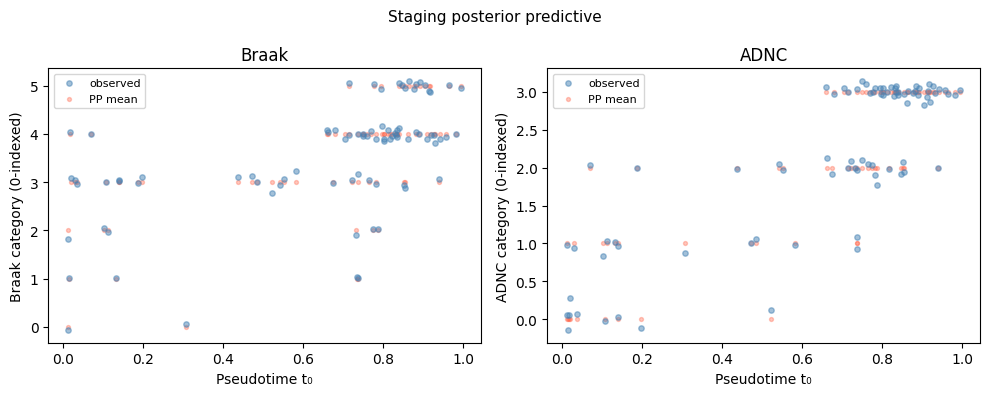

In [49]:
az_obj = results["az_objects"][-1]

fig, axes = plt.subplots(1, len(ord_cfg), figsize=(5 * len(ord_cfg), 4))
if len(ord_cfg) == 1:
    axes = [axes]

for ax, cfg in zip(axes, ord_cfg):
    name    = cfg["name"]
    obs_key = f"obs_{name}"
    obs_int = staging_obs[name].astype(float)
    obs_int[~staging_masks[name]] = np.nan
    valid   = ~np.isnan(obs_int)

    ax.scatter(times_mean[valid],
               obs_int[valid] + 0.08 * np.random.randn(valid.sum()),
               s=15, alpha=0.5, color="steelblue", label="observed", zorder=3)

    if obs_key in az_obj.posterior_predictive:
        pp = az_obj.posterior_predictive[obs_key].values.reshape(-1, T)
        pp_mean = pp.mean(0)
        ax.scatter(times_mean, pp_mean, s=8, alpha=0.35,
                   color="tomato", label="PP mean")

    ax.set_xlabel("Pseudotime t₀")
    ax.set_ylabel(f"{name} category (0-indexed)")
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.suptitle("Staging posterior predictive", fontsize=11)
plt.tight_layout()
plt.show()


 ## 6. Export

In [ ]:
donor_ids = df.index[initial_cond]
out = pd.DataFrame({
    "donor_id":   donor_ids,
    "times_mean": times_mean,
    "times_std":  times_std,
    "braak_int":  braak_int,
    "adnc_int":   adnc_int,
})
out.to_csv("pseudotime_seaad_mtg.csv", index=False)
print("Saved pseudotime_seaad_mtg.csv")
out.head(10)